In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import inspect
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, ShuffleSplit

#cv_splitter = ShuffleSplit(n_splits=5, train_size=0.8, test_size=0.2, random_state=42)
numeri_K = [1,2,3,4,5,6,7,8,9,10,20,30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160]
numero_cv= ShuffleSplit(n_splits=10, train_size=0.8, test_size=0.2, random_state=42)
csvcompleto = pd.read_csv("data.csv", sep=',', on_bad_lines='skip')
ribilanciamento = False

p_sterzo_0 = 0.10
p_sterzo_maggiore_0 = 0.45
p_sterzo_minore_0 = 0.45

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import numpy as np
import pandas as pd


# Verifica che le percentuali sommino a 1 (con un piccolo tolleranza per arrotondamenti)
assert abs(p_sterzo_0 + p_sterzo_maggiore_0 + p_sterzo_minore_0 - 1) < 0.01, "Le percentuali devono sommare a 1"

# Caricamento dati
df_originale = csvcompleto.copy()
df_processed = df_originale.copy()

if ribilanciamento:
    print("\nAvvio procedura di bilanciamento...")

    # Lavora su una copia per il bilanciamento
    df_balanced_working = df_processed.copy()

    # Rimuovi colonna temporanea se esiste
    if 'acceleration_binary' in df_balanced_working.columns:
        df_balanced_working = df_balanced_working.drop(columns=['acceleration_binary'])

    # Separo i dati per evitare una perdita di informazioni sul brake che è un dato già piccolo
    df_brake_nonzero = df_balanced_working[df_balanced_working['brake'] != 0].copy()
    df_brake_zero = df_balanced_working[df_balanced_working['brake'] == 0].copy()

    # Create categorical column for steering in the zero brake data
    df_brake_zero['steering_category'] = np.select(
        [df_brake_zero['steering'] == 0,
         df_brake_zero['steering'] < 0,
         df_brake_zero['steering'] > 0],
        [0, 1, 2]
    )

    print("\nDistribuzione iniziale delle classi (solo brake == 0):")
    display(df_brake_zero['steering_category'].value_counts(normalize=True))

    # Calcola numero di esempi per classe nel dataset con brake == 0
    counts = df_brake_zero['steering_category'].value_counts()
    n_current_0 = counts.get(0, 0)
    n_current_1 = counts.get(1, 0)
    n_current_2 = counts.get(2, 0)

    # Determina quali classi sono presenti
    classes_present = [c for c in [0, 1, 2] if counts.get(c, 0) > 0]

    if len(classes_present) < 2:
        print("\nAttenzione: Troppe classi vuote nel dataset brake == 0. Impossibile bilanciare questa parte.")
        df_processed = pd.concat([df_brake_zero.drop(columns=['steering_category']), df_brake_nonzero], ignore_index=True)
    else:
        # Calcola i target basati sulle percentuali desiderate
        total_target_samples = int(len(df_brake_zero) * (p_sterzo_0 + p_sterzo_maggiore_0 + p_sterzo_minore_0))
        target_0 = int(total_target_samples * p_sterzo_0)
        target_1 = int(total_target_samples * p_sterzo_minore_0)
        target_2 = int(total_target_samples * p_sterzo_maggiore_0)


        sampling_strategy = {
            0: min(n_current_0, target_0),
            1: min(n_current_1, target_1) if n_current_1 > 0 else 0,
            2: min(n_current_2, target_2) if n_current_2 > 0 else 0
        }

        # Rimuovi classi con 0 campioni dalla strategia di undersampling
        sampling_strategy = {k: v for k, v in sampling_strategy.items() if v > 0}


        print("\nStrategia di undersampling (solo brake == 0):", sampling_strategy)

        if len(sampling_strategy) >= 2:
            rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
            X_res, y_res = rus.fit_resample(
                df_brake_zero.drop(columns=['steering_category']),
                df_brake_zero['steering_category']
            )
            df_brake_zero_balanced = pd.concat([X_res, y_res], axis=1)

            print("\nDistribuzione dopo bilanciamento (solo brake == 0):")
            display(df_brake_zero_balanced['steering_category'].value_counts(normalize=True))

            # Combine balanced zero brake data with non-zero brake data
            df_processed = pd.concat([df_brake_zero_balanced.drop(columns=['steering_category']), df_brake_nonzero], ignore_index=True)

        else:
            print("\nImpossibile applicare undersampling con la strategia calcolata al dataset brake == 0")
            df_processed = pd.concat([df_brake_zero.drop(columns=['steering_category']), df_brake_nonzero], ignore_index=True)


else:
    print("\nBilanciamento disattivato. Dataset originale mantenuto.")
    df_processed = df_originale.copy()


# Salva il risultato
df_processed.to_csv('data_bilanciato.csv', index=False)
print("\nOperazione completata. Dataset salvato in 'data_bilanciato.csv'")
display(df_processed)


Bilanciamento disattivato. Dataset originale mantenuto.

Operazione completata. Dataset salvato in 'data_bilanciato.csv'


,track0,track2,track4,track6,track8,track10,track12,track14,track16,track18,speedX,angleToTrackAxis,trackPosition,distanceFromStartLine,steering,acceleration,brake
0,7.33374,7.82722,9.62860,14.7754,39.8054,21.1142,7.24756,4.75464,3.88989,3.66663,0.000304,0.008929,-0.333363,5759.10,0.000000,0.929411,0.0
1,7.33374,7.82722,9.62860,14.7754,39.8054,21.1142,7.24756,4.75464,3.88989,3.66663,0.000304,0.008929,-0.333363,5759.10,0.000000,0.921567,0.0
2,7.33374,7.82722,9.62860,14.7754,39.8054,21.1142,7.24756,4.75464,3.88989,3.66663,0.000304,0.008929,-0.333363,5759.10,0.000000,0.917631,0.0
3,7.33374,7.82722,9.62860,14.7754,39.8054,21.1142,7.24756,4.75464,3.88989,3.66663,0.000304,0.008929,-0.333363,5759.10,0.000000,0.913724,0.0
4,7.33374,7.82722,9.62860,14.7754,39.8054,21.1142,7.24756,4.75464,3.88989,3.66663,0.000304,0.008929,-0.333363,5759.10,0.000000,0.909787,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180777,6.69963,7.00605,8.40409,12.3619,30.2656,34.2499,9.41677,5.86919,4.67249,4.31328,172.804000,-0.048411,-0.216687,4099.32,0.005775,1.000000,0.0
180778,6.65152,6.95401,8.33907,12.2595,29.9558,34.8238,9.53512,5.93876,4.72622,4.36176,173.022000,-0.049103,-0.207909,4100.37,-0.007785,1.000000,0.0
180779,6.60242,6.90099,8.27294,12.1557,29.6445,35.4097,9.65581,6.00972,4.78104,4.41123,173.248000,-0.049787,-0.198952,4101.43,-0.011401,1.000000,0.0
180780,6.55222,6.84691,8.20571,12.0507,29.3340,36.0023,9.77864,6.08210,4.83702,4.46179,173.474000,-0.050442,-0.189797,4102.49,-0.005375,1.000000,0.0


In [ ]:
print(inspect.getsource(KNeighborsRegressor.predict))

    def predict(self, X):
        """Predict the target for the provided data.

        Parameters
        ----------
        X : {array-like, sparse matrix} of shape (n_queries, n_features), \
                or (n_queries, n_indexed) if metric == 'precomputed', or None
            Test samples. If `None`, predictions for all indexed points are
            returned; in this case, points are not considered their own
            neighbors.

        Returns
        -------
        y : ndarray of shape (n_queries,) or (n_queries, n_outputs), dtype=int
            Target values.
        """
        if self.weights == "uniform":
            # In that case, we do not need the distances to perform
            # the weighting so we do not compute them.
            neigh_ind = self.kneighbors(X, return_distance=False)
            neigh_dist = None
        else:
            neigh_dist, neigh_ind = self.kneighbors(X)

        weights = _get_weights(neigh_dist, self.weights)

        _y = self._y


In [ ]:
csvcompleto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180782 entries, 0 to 180781
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   track0                 180782 non-null  float64
 1   track2                 180782 non-null  float64
 2   track4                 180782 non-null  float64
 3   track6                 180782 non-null  float64
 4   track8                 180782 non-null  float64
 5   track10                180782 non-null  float64
 6   track12                180782 non-null  float64
 7   track14                180782 non-null  float64
 8   track16                180782 non-null  float64
 9   track18                180782 non-null  float64
 10  speedX                 180782 non-null  float64
 11  angleToTrackAxis       180782 non-null  float64
 12  trackPosition          180782 non-null  float64
 13  distanceFromStartLine  180782 non-null  float64
 14  steering               180782 non-nu

In [ ]:
features = csvcompleto.iloc[:,:14]
features

,track0,track2,track4,track6,track8,track10,track12,track14,track16,track18,speedX,angleToTrackAxis,trackPosition,distanceFromStartLine
0,7.33374,7.82722,9.62860,14.7754,39.8054,21.1142,7.24756,4.75464,3.88989,3.66663,0.000304,0.008929,-0.333363,5759.10
1,7.33374,7.82722,9.62860,14.7754,39.8054,21.1142,7.24756,4.75464,3.88989,3.66663,0.000304,0.008929,-0.333363,5759.10
2,7.33374,7.82722,9.62860,14.7754,39.8054,21.1142,7.24756,4.75464,3.88989,3.66663,0.000304,0.008929,-0.333363,5759.10
3,7.33374,7.82722,9.62860,14.7754,39.8054,21.1142,7.24756,4.75464,3.88989,3.66663,0.000304,0.008929,-0.333363,5759.10
4,7.33374,7.82722,9.62860,14.7754,39.8054,21.1142,7.24756,4.75464,3.88989,3.66663,0.000304,0.008929,-0.333363,5759.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180777,6.69963,7.00605,8.40409,12.3619,30.2656,34.2499,9.41677,5.86919,4.67249,4.31328,172.804000,-0.048411,-0.216687,4099.32
180778,6.65152,6.95401,8.33907,12.2595,29.9558,34.8238,9.53512,5.93876,4.72622,4.36176,173.022000,-0.049103,-0.207909,4100.37
180779,6.60242,6.90099,8.27294,12.1557,29.6445,35.4097,9.65581,6.00972,4.78104,4.41123,173.248000,-0.049787,-0.198952,4101.43
180780,6.55222,6.84691,8.20571,12.0507,29.3340,36.0023,9.77864,6.08210,4.83702,4.46179,173.474000,-0.050442,-0.189797,4102.49


In [ ]:
max = features.max()
max

,0
track0,200.00000
track2,200.00000
track4,200.00000
track6,200.00000
track8,200.00000
track10,200.00000
track12,200.00000
track14,200.00000
track16,200.00000
track18,200.00000


In [ ]:
min_features = features.min()
display(min_features)

,0
track0,-1.000000
track2,-1.000000
track4,-1.000000
track6,-1.000000
track8,-1.000000
track10,-1.000000
track12,-1.000000
track14,-1.000000
track16,-1.000000
track18,-1.000000


In [ ]:
labels = csvcompleto.iloc[:,-3:]
labels

,steering,acceleration,brake
0,0.000000,0.929411,0.0
1,0.000000,0.921567,0.0
2,0.000000,0.917631,0.0
3,0.000000,0.913724,0.0
4,0.000000,0.909787,0.0
...,...,...,...
180777,0.005775,1.000000,0.0
180778,-0.007785,1.000000,0.0
180779,-0.011401,1.000000,0.0
180780,-0.005375,1.000000,0.0


In [ ]:
print('Valori statistici per tutte le proprietà')
display(csvcompleto.describe()) # valori statistici

Valori statistici per tutte le proprietà


,track0,track2,track4,track6,track8,track10,track12,track14,track16,track18,speedX,angleToTrackAxis,trackPosition,distanceFromStartLine,steering,acceleration,brake
count,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000,180782.000000
mean,5.362355,5.748189,7.027917,10.650868,32.049435,38.513733,10.661990,6.813446,5.554437,5.249759,173.204868,-0.003212,-0.002431,3084.778838,-0.007898,0.765335,0.028390
std,2.718487,3.486551,3.902702,5.250672,21.711287,28.643907,6.179056,3.285528,2.898627,3.321859,55.570053,0.224754,0.733576,1504.350124,0.115526,0.358714,0.126769
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-13.696300,-3.141460,-6.485390,0.260071,-1.000000,0.000000,0.000000
25%,3.926185,4.180248,5.127370,7.840515,21.390025,23.292825,7.450138,4.837942,3.938788,3.699733,136.114000,-0.017152,-0.306750,1962.820000,-0.024658,0.635273,0.000000
50%,5.403520,5.750625,7.040845,10.721600,28.782150,33.275250,10.901350,7.062835,5.751355,5.405005,171.315500,0.002595,0.000402,3126.395000,-0.000215,1.000000,0.000000
75%,7.065435,7.521905,9.196740,13.902175,38.246275,45.140975,13.773900,8.940520,7.286070,6.847170,216.411000,0.022758,0.263713,4100.172500,0.002621,1.000000,0.000000
max,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,288.852000,3.141000,7.056530,5784.060000,1.000000,1.000000,1.000000


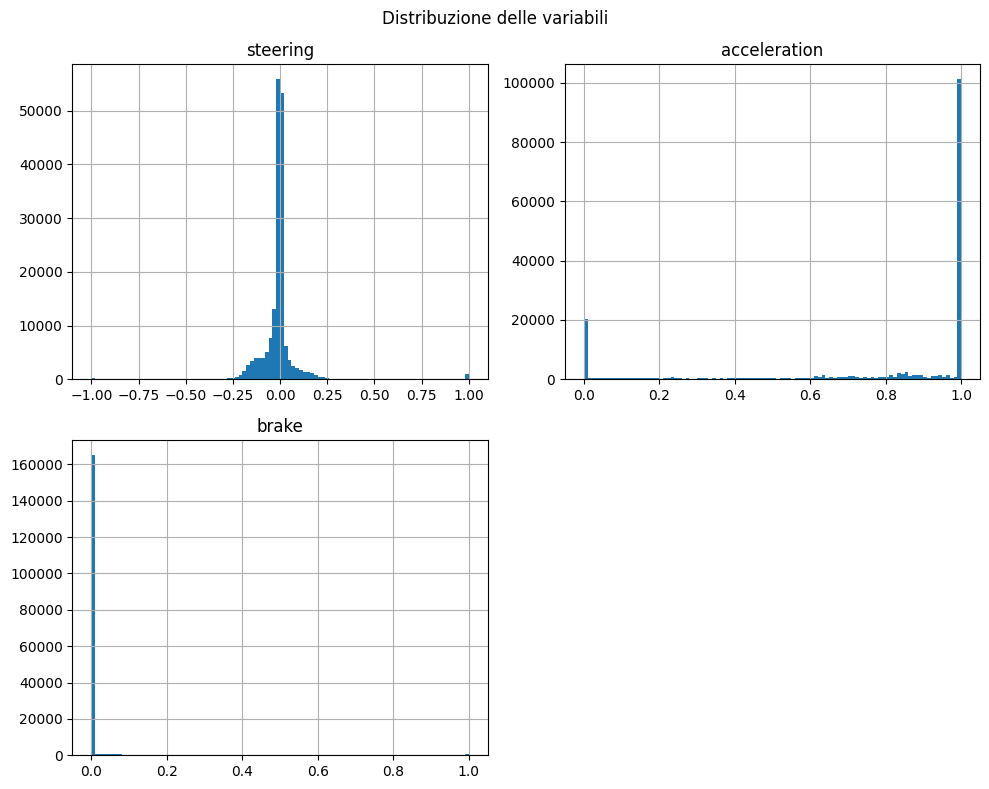

In [ ]:
labels.hist(bins=100, figsize=(10, 8))
plt.suptitle('Distribuzione delle variabili')
plt.tight_layout()
plt.show()

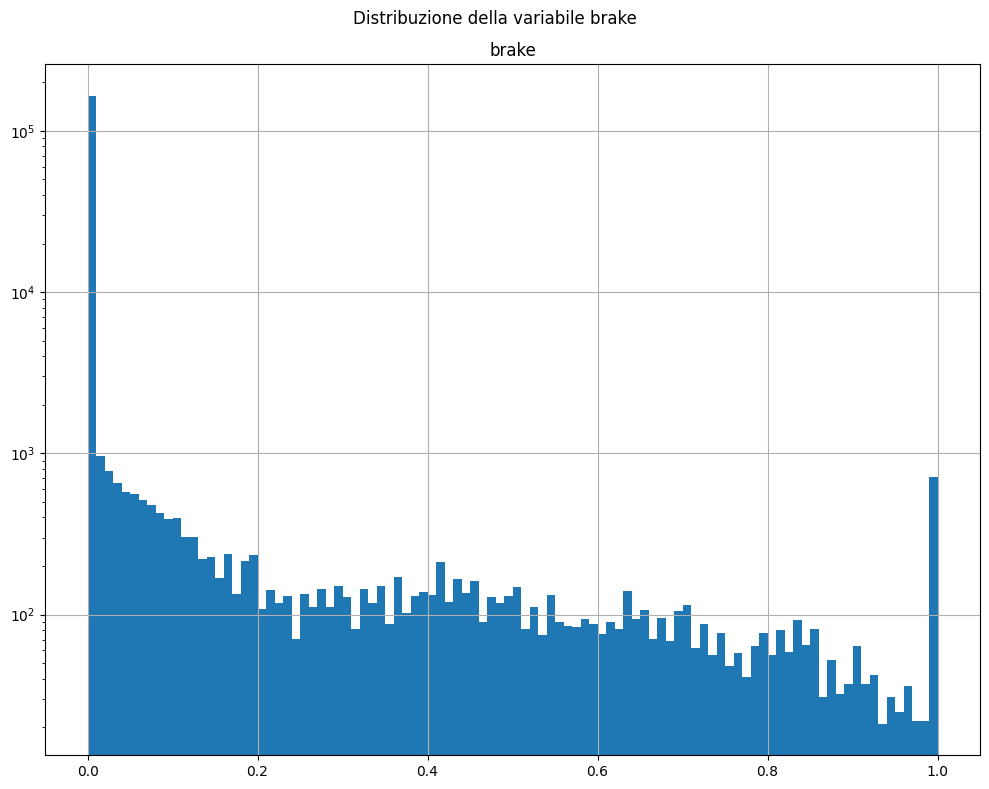

In [ ]:
labels[['brake']].hist(bins=100, figsize=(10, 8))
plt.suptitle('Distribuzione della variabile brake')
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.tight_layout()
plt.show()

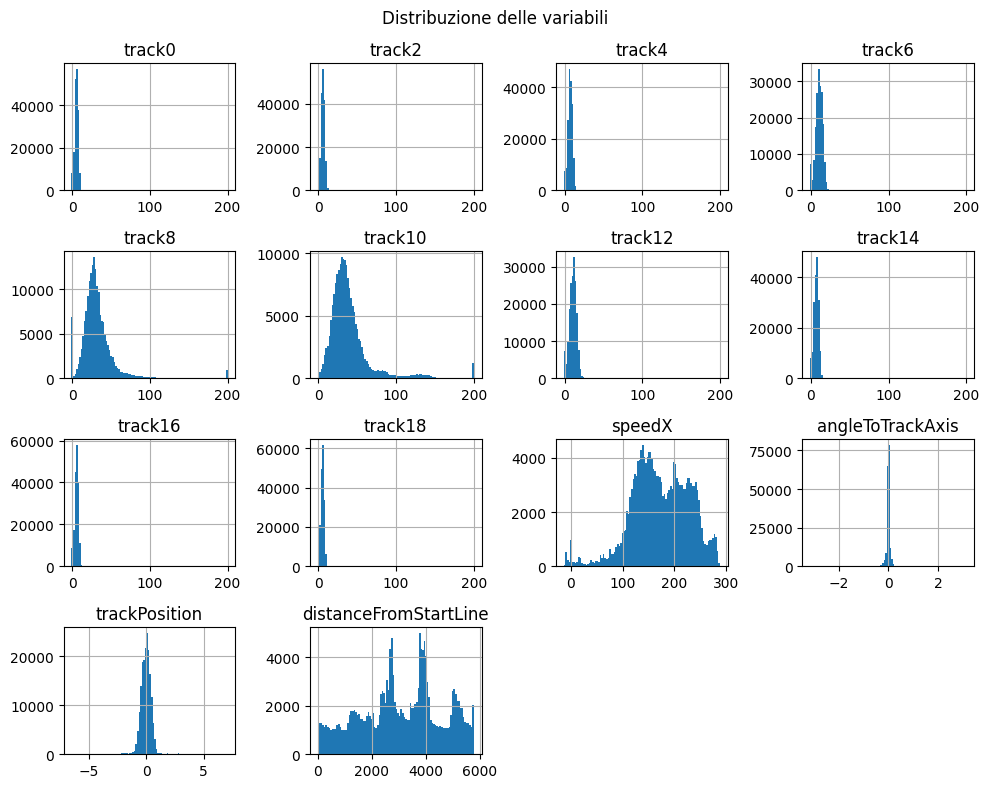

In [ ]:
features.hist(bins=100, figsize=(10, 8))
plt.suptitle('Distribuzione delle variabili')
plt.tight_layout()
plt.show()

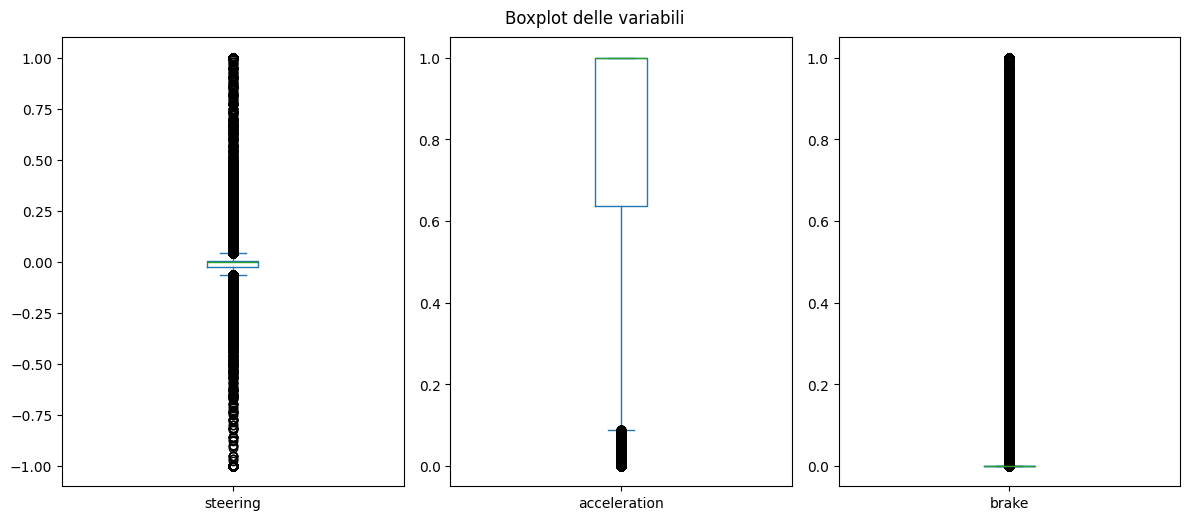

In [ ]:
csvcompleto[['steering', 'acceleration', 'brake']].plot(kind='box', subplots=True, layout=(2,3), figsize=(12, 10), title='Boxplot delle variabili')
plt.tight_layout()
plt.show()

In [ ]:
#xNew0 = MinMaxScaler().fit_transform(features) #valori delle features dopo la normalizzazione standard
#pd.DataFrame(xNew0, columns=features.columns)

In [ ]:
#import inspect
#from sklearn.preprocessing import MinMaxScaler

#print(inspect.getsource(MinMaxScaler.fit_transform))


In [ ]:
#featuresNorm = features / features.max()
#featuresNorm

In [ ]:
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor(metric='minkowski', p=1))
    ])

modello = GridSearchCV(estimator=pipe,
             param_grid={'model__n_neighbors': numeri_K},
             cv=numero_cv)

In [ ]:
modello.fit(features,labels)
pd.DataFrame(modello.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.483876,0.056350,1.390506,0.259924,1,{'model__n_neighbors': 1},0.900730,0.900497,0.909429,0.905511,0.905585,0.910832,0.904213,0.911373,0.904614,0.909818,0.906260,0.003761,3
1,0.486779,0.089539,1.879619,0.328594,2,{'model__n_neighbors': 2},0.919450,0.916343,0.922444,0.922344,0.918314,0.921402,0.920228,0.924491,0.920264,0.922126,0.920741,0.002220,1
2,0.484855,0.089025,2.513753,0.350927,3,{'model__n_neighbors': 3},0.910425,0.907991,0.914111,0.915110,0.910445,0.912896,0.910839,0.916292,0.913569,0.910617,0.912230,0.002440,2
3,0.521223,0.126861,2.931115,0.327919,4,{'model__n_neighbors': 4},0.897708,0.897014,0.905068,0.903767,0.897813,0.900017,0.896779,0.904333,0.902703,0.897535,0.900274,0.003172,4
4,0.520092,0.117511,3.377089,0.356244,5,{'model__n_neighbors': 5},0.885190,0.885588,0.893451,0.890884,0.887008,0.887118,0.885085,0.893052,0.890021,0.885067,0.888246,0.003156,5
5,0.557336,0.141586,3.780461,0.331681,6,{'model__n_neighbors': 6},0.873158,0.873544,0.880572,0.879757,0.875979,0.875944,0.873896,0.881362,0.878229,0.874459,0.876690,0.002914,6
6,0.490100,0.096973,4.142785,0.371427,7,{'model__n_neighbors': 7},0.861481,0.862977,0.868598,0.868311,0.865026,0.865049,0.863403,0.869497,0.867683,0.863301,0.865533,0.002653,7
7,0.501103,0.092282,4.448970,0.404271,8,{'model__n_neighbors': 8},0.849363,0.852901,0.857712,0.856805,0.854894,0.854298,0.851949,0.859054,0.857018,0.853276,0.854727,0.002817,8
8,0.533231,0.120076,4.921684,0.494986,9,{'model__n_neighbors': 9},0.838170,0.842027,0.846904,0.847248,0.844628,0.843459,0.841321,0.847493,0.847859,0.842479,0.844159,0.003064,9
9,0.477383,0.014075,5.117992,0.528346,10,{'model__n_neighbors': 10},0.827515,0.831828,0.836669,0.837027,0.834513,0.832941,0.830821,0.837160,0.837183,0.831961,0.833762,0.003135,10


In [ ]:
pipe2 = Pipeline([
    ("scale", QuantileTransformer()),
    ("model", KNeighborsRegressor(metric='minkowski', p=1))
])

modello2 = GridSearchCV(estimator=pipe2,
                       param_grid={'model__n_neighbors': numeri_K},
                       cv=numero_cv)

In [ ]:
modello2.fit(features,labels)
pd.DataFrame(modello2.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.900263,0.092803,0.995840,0.194326,1,{'model__n_neighbors': 1},0.885625,0.886104,0.888410,0.889303,0.884746,0.890650,0.885817,0.893810,0.884782,0.892594,0.888184,0.003136,3
1,0.941135,0.153374,1.221190,0.185215,2,{'model__n_neighbors': 2},0.905248,0.904687,0.907607,0.909029,0.902693,0.907102,0.903633,0.910489,0.905162,0.911083,0.906673,0.002720,1
2,0.903131,0.068972,1.574308,0.318587,3,{'model__n_neighbors': 3},0.896049,0.900305,0.902802,0.899306,0.892012,0.901408,0.894602,0.901923,0.898840,0.900415,0.898766,0.003301,2
3,0.943191,0.142478,1.744369,0.216309,4,{'model__n_neighbors': 4},0.883758,0.887841,0.890426,0.886639,0.883212,0.889628,0.883751,0.890087,0.887767,0.889078,0.887219,0.002624,4
4,0.937174,0.130704,2.036174,0.344682,5,{'model__n_neighbors': 5},0.872898,0.877151,0.879562,0.876900,0.872787,0.878179,0.870216,0.880338,0.876193,0.878336,0.876256,0.003108,5
5,0.944762,0.142174,2.144516,0.250027,6,{'model__n_neighbors': 6},0.863072,0.866504,0.868279,0.864060,0.861225,0.866301,0.859986,0.866821,0.865483,0.867000,0.864873,0.002571,6
6,0.954995,0.154225,2.416762,0.334426,7,{'model__n_neighbors': 7},0.853240,0.855567,0.857222,0.854154,0.849924,0.854302,0.850032,0.855385,0.854611,0.855929,0.854037,0.002278,7
7,0.940498,0.107760,2.580372,0.329878,8,{'model__n_neighbors': 8},0.841714,0.843301,0.845078,0.844111,0.840242,0.842344,0.839184,0.842681,0.845168,0.845733,0.842956,0.002053,8
8,0.911817,0.119249,2.758539,0.430043,9,{'model__n_neighbors': 9},0.831306,0.834021,0.835873,0.833004,0.829434,0.833732,0.829566,0.831151,0.832401,0.835042,0.832553,0.002077,9
9,0.934255,0.139385,2.870695,0.369557,10,{'model__n_neighbors': 10},0.822589,0.823122,0.824602,0.822535,0.819169,0.823596,0.820007,0.822863,0.821773,0.823960,0.822422,0.001614,10


In [ ]:
'''colonneTrack = list(range(0,10))
for col in colonneTrack:
    maxVal = features.iloc[:,col].max()
    if maxVal != 0:
        features.iloc[:,col] = features.iloc[:,col]/maxVal

colonnaATTA = 11
angleRange = 2*math.pi
features.iloc[:,colonnaATTA] = (features.iloc[:,colonnaATTA] + math.pi)/angleRange
features.iloc[:,colonnaATTA] = np.clip(features.iloc[:, colonnaATTA], 0.0, 1.0)

colonnaTrackPos = 12
features.iloc[:,colonnaTrackPos] = np.clip((features.iloc[:, colonnaTrackPos] + 1.0) / 2.0, 0.0, 1.0)

colonneSpeedDist = [10,13]
scaler = MinMaxScaler()
features.iloc[:,colonneSpeedDist] = scaler.fit_transform(features.iloc[:,colonneSpeedDist])

features '''

'colonneTrack = list(range(0,10))\nfor col in colonneTrack:\n    maxVal = features.iloc[:,col].max()\n    if maxVal != 0:\n        features.iloc[:,col] = features.iloc[:,col]/maxVal\n\ncolonnaATTA = 11\nangleRange = 2*math.pi\nfeatures.iloc[:,colonnaATTA] = (features.iloc[:,colonnaATTA] + math.pi)/angleRange\nfeatures.iloc[:,colonnaATTA] = np.clip(features.iloc[:, colonnaATTA], 0.0, 1.0)\n\ncolonnaTrackPos = 12\nfeatures.iloc[:,colonnaTrackPos] = np.clip((features.iloc[:, colonnaTrackPos] + 1.0) / 2.0, 0.0, 1.0)\n\ncolonneSpeedDist = [10,13]\nscaler = MinMaxScaler()\nfeatures.iloc[:,colonneSpeedDist] = scaler.fit_transform(features.iloc[:,colonneSpeedDist])\n\nfeatures '

In [ ]:
import numpy as np
import math

# Copia per non modificare in place se non vuoi
features = features.copy()

# Track sensors (indici 0-9) -> [0, 200] -> [0, 10]
for col in range(0, 10):
    features.iloc[:, col] = np.where(
        features.iloc[:, col] < 0,
        0.0,
        np.clip(features.iloc[:, col] / 200.0, 0.0, 1.0) * 10.0
    )

# speedX (indice 10) -> [0, 288] -> [0, 10]
features.iloc[:, 10] = np.clip(features.iloc[:, 10] / 288.0, 0.0, 1.0) * 10.0

# angleToTrackAxis (indice 11) -> [-π, π] -> [0, 10]
features.iloc[:, 11] = np.clip(
    (features.iloc[:, 11] + math.pi) / (2 * math.pi),
    0.0, 1.0
) * 10.0

# trackPosition (indice 12) -> [-1, 1] -> [0, 10]
features.iloc[:, 12] = np.clip(
    (features.iloc[:, 12] + 1.0) / 2.0,
    0.0, 1.0
) * 10.0

# distanceFromStartLine (indice 13) -> [0, 5784.10] -> [0, 10]
features.iloc[:, 13] = np.clip(
    features.iloc[:, 13] / 5784.10,
    0.0, 1.0
) * 10.0

print("Features normalizzate:")
display(features)
print("Max features")
display(features.max())
print("Min features")
display(features.min())

Features normalizzate:


,track0,track2,track4,track6,track8,track10,track12,track14,track16,track18,speedX,angleToTrackAxis,trackPosition,distanceFromStartLine
0,0.366687,0.391361,0.481430,0.738770,1.990270,1.055710,0.362378,0.237732,0.194495,0.183331,0.000011,5.014210,3.333185,9.956778
1,0.366687,0.391361,0.481430,0.738770,1.990270,1.055710,0.362378,0.237732,0.194495,0.183331,0.000011,5.014210,3.333185,9.956778
2,0.366687,0.391361,0.481430,0.738770,1.990270,1.055710,0.362378,0.237732,0.194495,0.183331,0.000011,5.014210,3.333185,9.956778
3,0.366687,0.391361,0.481430,0.738770,1.990270,1.055710,0.362378,0.237732,0.194495,0.183331,0.000011,5.014210,3.333185,9.956778
4,0.366687,0.391361,0.481430,0.738770,1.990270,1.055710,0.362378,0.237732,0.194495,0.183331,0.000011,5.014210,3.333185,9.956778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180777,0.334981,0.350302,0.420204,0.618095,1.513280,1.712495,0.470838,0.293459,0.233625,0.215664,6.000139,4.922952,3.916565,7.087222
180778,0.332576,0.347701,0.416953,0.612975,1.497790,1.741190,0.476756,0.296938,0.236311,0.218088,6.007708,4.921850,3.960455,7.089037
180779,0.330121,0.345050,0.413647,0.607785,1.482225,1.770485,0.482791,0.300486,0.239052,0.220561,6.015556,4.920761,4.005240,7.090870
180780,0.327611,0.342346,0.410285,0.602535,1.466700,1.800115,0.488932,0.304105,0.241851,0.223089,6.023403,4.919720,4.051015,7.092702


Max features


,0
track0,10.000000
track2,10.000000
track4,10.000000
track6,10.000000
track8,10.000000
track10,10.000000
track12,10.000000
track14,10.000000
track16,10.000000
track18,10.000000


Min features


,0
track0,0.000000
track2,0.000000
track4,0.000000
track6,0.000000
track8,0.000000
track10,0.000000
track12,0.000000
track14,0.000000
track16,0.000000
track18,0.000000


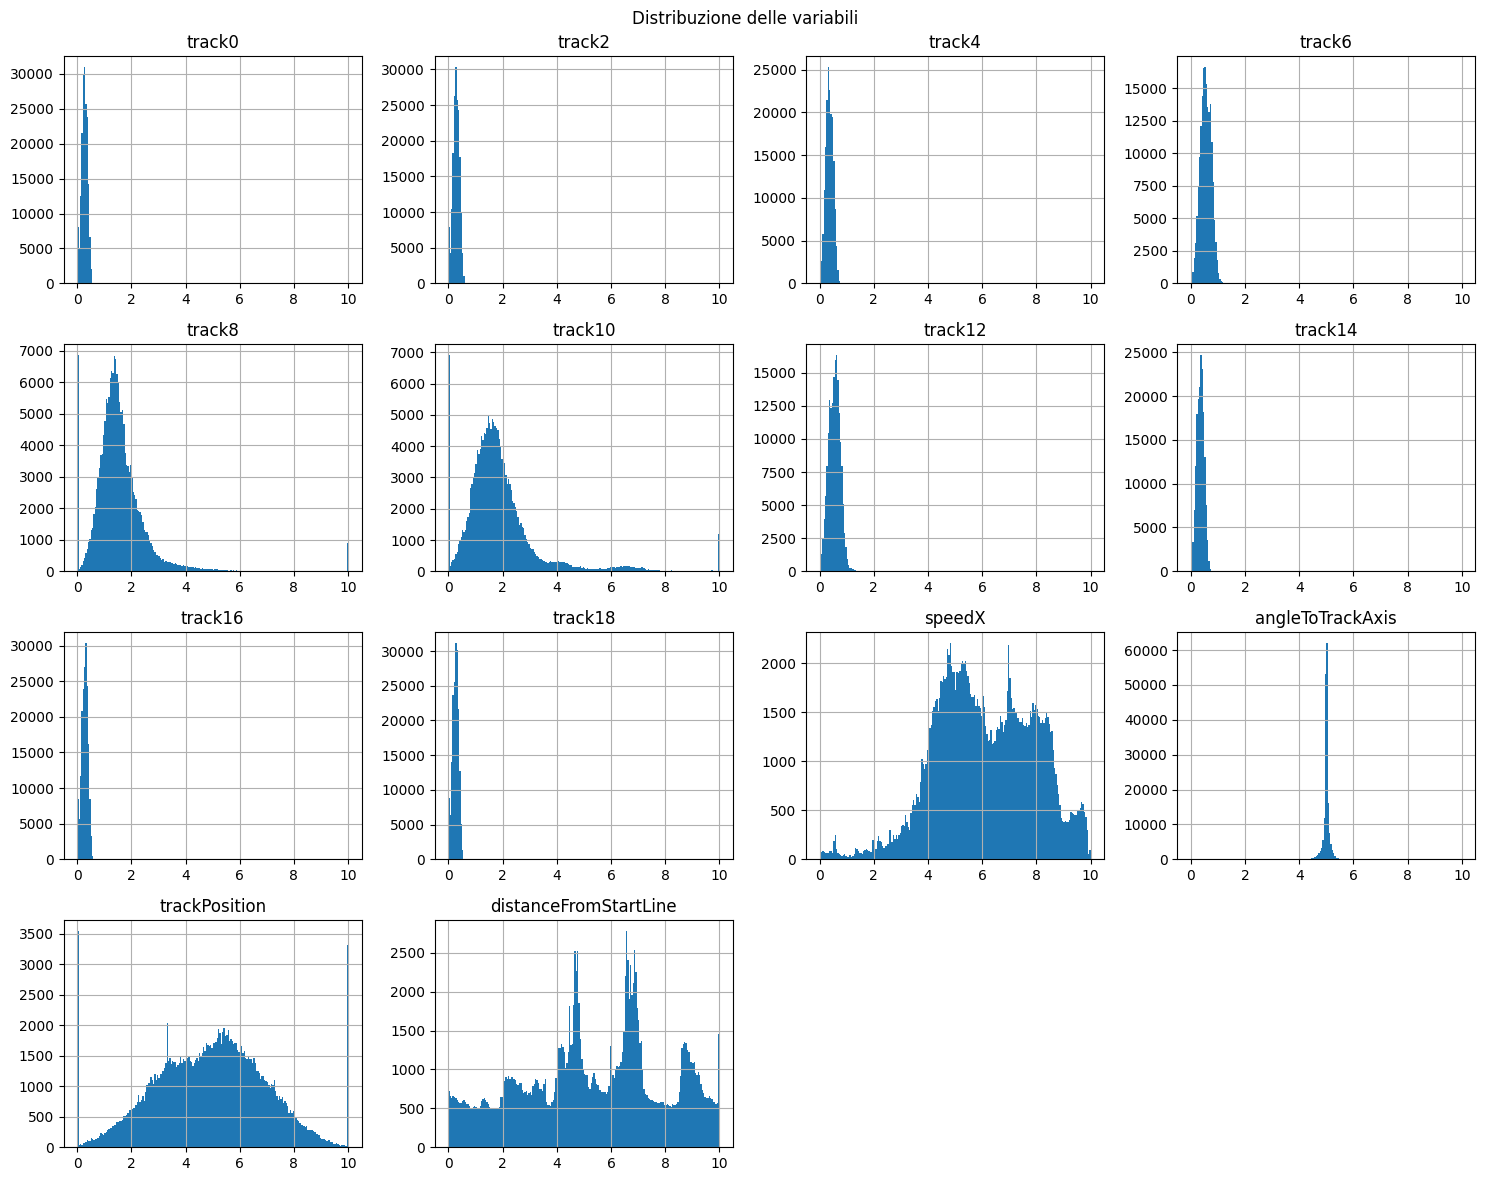

In [ ]:
features.hist(bins=200, figsize=(15, 12))
plt.suptitle('Distribuzione delle variabili')
plt.tight_layout()
plt.show()

In [ ]:
gridsearch = GridSearchCV(estimator=KNeighborsRegressor(metric='minkowski', p=1),
             param_grid={'n_neighbors': numeri_K},
             cv=numero_cv)

gridsearch.fit(features,labels)
pd.DataFrame(gridsearch.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.493607,0.094391,0.971978,0.145391,1,{'n_neighbors': 1},0.933260,0.931855,0.933408,0.933226,0.933536,0.934782,0.935722,0.938903,0.932782,0.937317,0.934479,0.002100,3
1,0.471171,0.056476,1.206959,0.228948,2,{'n_neighbors': 2},0.940173,0.943928,0.941205,0.942079,0.941303,0.942365,0.945729,0.947713,0.943647,0.944735,0.943288,0.002202,1
2,0.471236,0.066852,1.624520,0.346795,3,{'n_neighbors': 3},0.935101,0.939453,0.939052,0.937271,0.937508,0.939384,0.940507,0.943094,0.939378,0.937563,0.938831,0.002043,2
3,0.490676,0.099350,1.839334,0.297685,4,{'n_neighbors': 4},0.927411,0.931510,0.932674,0.930621,0.930251,0.932116,0.932919,0.935717,0.932237,0.928626,0.931408,0.002221,4
4,0.506180,0.122292,2.097367,0.210486,5,{'n_neighbors': 5},0.919454,0.923632,0.924082,0.921931,0.921483,0.923775,0.924459,0.927087,0.924106,0.919570,0.922958,0.002236,5
5,0.477122,0.091340,2.348115,0.321307,6,{'n_neighbors': 6},0.910966,0.915612,0.914637,0.914336,0.913475,0.915230,0.915340,0.919740,0.917067,0.911137,0.914754,0.002465,6
6,0.503272,0.120285,2.594969,0.143761,7,{'n_neighbors': 7},0.902056,0.906974,0.905699,0.906388,0.905289,0.905749,0.907480,0.910189,0.910323,0.902440,0.906259,0.002603,7
7,0.492391,0.107996,2.780124,0.334716,8,{'n_neighbors': 8},0.892848,0.899071,0.897627,0.899430,0.896902,0.897611,0.899360,0.901937,0.901347,0.893688,0.897982,0.002800,8
8,0.472139,0.091758,2.983715,0.406298,9,{'n_neighbors': 9},0.884172,0.891290,0.888437,0.891022,0.888971,0.889324,0.891090,0.892696,0.893558,0.884702,0.889526,0.002959,9
9,0.498447,0.123467,3.118829,0.312603,10,{'n_neighbors': 10},0.876062,0.882478,0.880181,0.883423,0.881204,0.881684,0.882489,0.884388,0.885239,0.876510,0.881366,0.002900,10


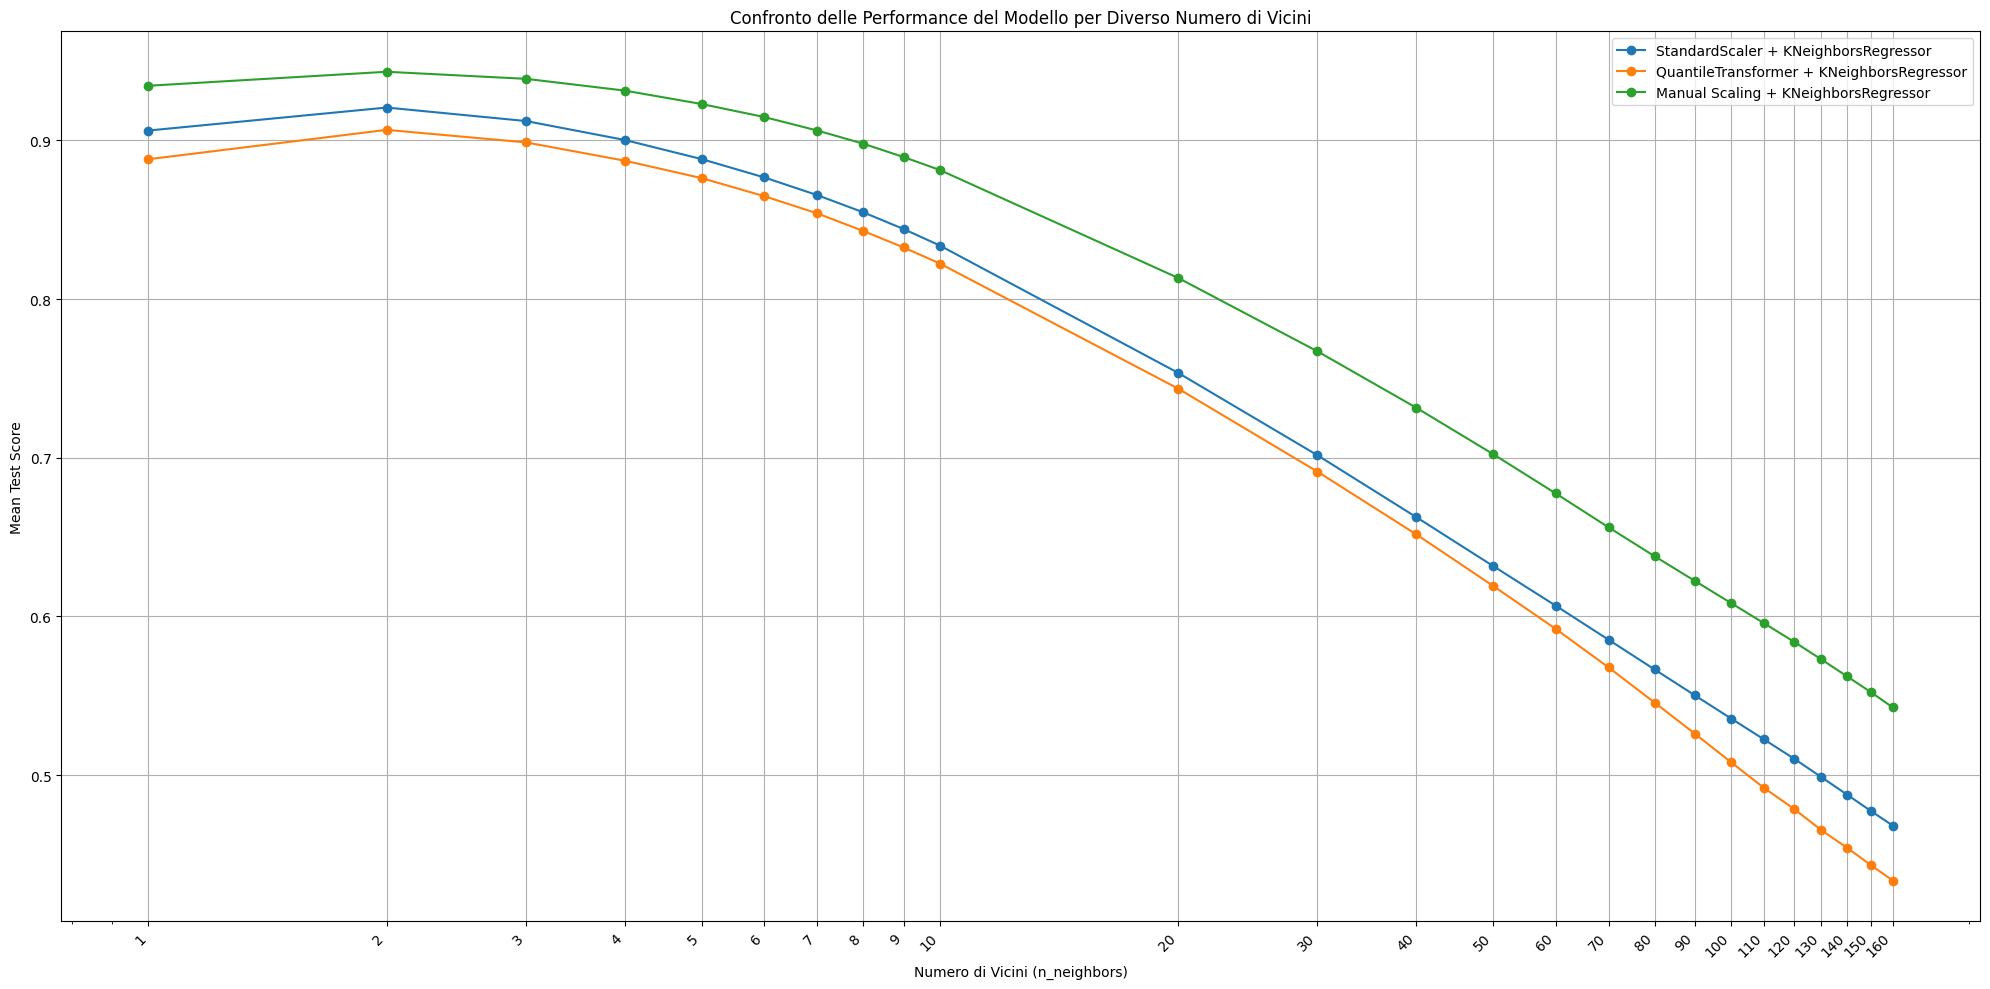


 Migliore performance per StandardScaler + KNeighborsRegressor:


{'model__n_neighbors': 2}

np.float64(0.9207405909217556)


 Migliore performance per QuantileTransformer + KNeighborsRegressor:


{'model__n_neighbors': 2}

np.float64(0.9066731970564732)


 Migliore performance per Manual Scaling + KNeighborsRegressor:


{'n_neighbors': 2}

np.float64(0.9432877834464597)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ottengo i risultati di GridSearchCV per entrambi i modelli
results_modello = pd.DataFrame(modello.cv_results_)
results_modello2 = pd.DataFrame(modello2.cv_results_)
results_gridsearch = pd.DataFrame(gridsearch.cv_results_)


# Estraggo il numero di vicini e il mean_test_score
n_neighbors_modello = results_modello['param_model__n_neighbors']
mean_test_score_modello = results_modello['mean_test_score']

n_neighbors_modello2 = results_modello2['param_model__n_neighbors']
mean_test_score_modello2 = results_modello2['mean_test_score']

n_neighbors_gridsearch = results_gridsearch['param_n_neighbors']
mean_test_score_gridsearch = results_gridsearch['mean_test_score']


# grafico per confrontare i mean_test_score
plt.figure(figsize=(20, 10))
plt.plot(n_neighbors_modello, mean_test_score_modello, marker='o', linestyle='-', label='StandardScaler + KNeighborsRegressor')
plt.plot(n_neighbors_modello2, mean_test_score_modello2, marker='o', linestyle='-', label='QuantileTransformer + KNeighborsRegressor')
plt.plot(n_neighbors_gridsearch, mean_test_score_gridsearch, marker='o', linestyle='-', label='Manual Scaling + KNeighborsRegressor')


plt.xlabel('Numero di Vicini (n_neighbors)')
plt.ylabel('Mean Test Score')
plt.title('Confronto delle Performance del Modello per Diverso Numero di Vicini')
plt.grid(True)
plt.legend()
plt.xscale('log') # Utilizza scala logaritmica per l'asse x se numeri_K ha un ampio range
#plt.xscale('linear') # Utilizza scala lineare per l'asse x se numeri_K ha un range più piccolo
plt.xticks(numeri_K, labels=numeri_K, rotation=45, ha='right') # Mostra tutti i valori di numeri_K sull'asse x
plt.tight_layout()
plt.show()


print("\n Migliore performance per StandardScaler + KNeighborsRegressor:")
display(modello.best_params_)
display(modello.best_score_)

print("\n Migliore performance per QuantileTransformer + KNeighborsRegressor:")
display(modello2.best_params_)
display(modello2.best_score_)

print("\n Migliore performance per Manual Scaling + KNeighborsRegressor:")
display(gridsearch.best_params_)
display(gridsearch.best_score_)

In [ ]:
minNorm = features.min()
minNorm

,0
track0,0.000000
track2,0.000000
track4,0.000000
track6,0.000000
track8,0.000000
track10,0.000000
track12,0.000000
track14,0.000000
track16,0.000000
track18,0.000000


In [ ]:
maxNorm = features.max()
maxNorm

,0
track0,10.000000
track2,10.000000
track4,10.000000
track6,10.000000
track8,10.000000
track10,10.000000
track12,10.000000
track14,10.000000
track16,10.000000
track18,10.000000
